# Uncertainty Tracking Under Label Noise

Point-prediction robustness (see `01_quickstart.ipynb`) tells you *how fast accuracy
degrades* as labels get noisier. A probabilistic model can do more: its **per-sample
uncertainty** should grow on the predictions it is getting wrong, and ideally flag the
samples whose labels were corrupted.

`calculate_uncertainty_metrics` evaluates that calibration across noise levels:

- **uncertainty–error ρ** — Spearman correlation between predicted uncertainty and
  absolute error (does the model know when it is wrong?)
- **coverage at 1σ / 2σ** — fraction of test points inside $\hat y \pm k\hat u$
  (Gaussian targets 68% / 95%)
- **ECE** — expected calibration error, binning by predicted uncertainty
- **mean interval width** — average $2\hat u$, the sharpness of the intervals
- **uncertainty–noise ρ** — Spearman correlation between predicted uncertainty and the
  *injected* noise magnitude on the training set (does the model notice corrupted labels?)

We use **NGBoost** here — the model that was most robust to label noise in the paper.
It learns a per-sample mean *and scale*, so its uncertainty can grow specifically on the
samples whose labels were corrupted. The `noiseInject[uncertainty]` extra ships thin
wrappers (`GaucheGPRegressor`, `SplitConformalRegressor`, `MCDropoutRegressor`) that
produce the same `(mean, uncertainty)` interface for fingerprint GPs, any sklearn model,
and PyTorch networks respectively.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from ngboost import NGBRegressor
from ngboost.distns import Normal

from noiseInject import NoiseInjectorRegression, calculate_uncertainty_metrics

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data and a probabilistic model

NGBoost fits a gradient-boosted `Normal(loc, scale)` for every sample. The `scale` head
is the per-sample predicted uncertainty $\hat u$ we feed to the metrics — and because it
is learned from the data, it can grow on the samples whose labels were corrupted.

We use the synthetic Friedman-1 target with **zero intrinsic noise**, so $\sigma = 0$ is a
genuinely clean baseline. This mirrors the paper's QM9 setting (quantum-mechanical labels
with no measurement noise), where injected noise is fully attributable — unlike the
experimental ADME endpoints, which carry an unknown noise floor that masks the signal.

In [2]:
X, y = make_friedman1(n_samples=1200, n_features=8, noise=0.0, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE)

def make_model():
    return NGBRegressor(Dist=Normal, n_estimators=500, learning_rate=0.03,
                        verbose=False, random_state=RANDOM_STATE)

def predict_mean_std(model, X):
    dist = model.pred_dist(X)
    return dist.loc, dist.scale  # Normal: loc = mean, scale = predicted std

print(f'train={X_train.shape[0]}  test={X_test.shape[0]}  features={X_train.shape[1]}')

train=840  test=360  features=8


## 2. Sweep noise levels, tracking predictions *and* uncertainty

At each noise level we corrupt the **training** labels, refit the GP, and record:

- test-set `(mean, std)` — for the calibration metrics against clean test targets, and
- train-set `std` together with the injected noise `y_noisy - y_clean` — for the
  uncertainty–noise correlation.

In [ ]:
# The level is the amount of noise DELIVERED, as a fraction of the label spread.
# Nothing to calibrate: every condition solves for the scale that hits it.
label_sd = float(np.std(y_train))
condition = 'gaussian'
levels = [0.0, 0.15, 0.30, 0.45]

predictions, uncertainties = {}, {}
injected_noise, noise_uncertainties = {}, {}

for k in levels:
    level = k * label_sd
    injector = NoiseInjectorRegression.from_condition(condition, random_state=RANDOM_STATE)
    result = injector.inject_verbose(y_train, dose=level)
    y_noisy = result.y_noisy

    model = make_model().fit(X_train, y_noisy)

    mean_test, std_test = predict_mean_std(model, X_test)
    predictions[level] = mean_test
    uncertainties[level] = std_test

    # RECORD the perturbation, never reconstruct it. `result.epsilon` is the
    # draw itself, and at level 0.0 it is exactly zero -- a real negative
    # control. Recovering it by differencing or by regression gives you
    # floating-point rounding at level zero, whose size grows with the label,
    # which is exactly where uncertainty is largest.
    _, std_train = predict_mean_std(model, X_train)
    injected_noise[level] = result.epsilon
    noise_uncertainties[level] = std_train

    print(f'level={k:>5}  dose={level:6.2f}  delivered={result.delivered_dose:6.2f}'
          f'  mean test std={std_test.mean():6.2f}')

## 3. Compute the uncertainty metrics

In [4]:
per_sigma_df, summary_df = calculate_uncertainty_metrics(
    y_test, predictions, uncertainties,
    injected_noise=injected_noise, noise_uncertainties=noise_uncertainties,
)
per_sigma_df.round(3)

,sigma,unc_error_rho,ece,coverage_1sigma,coverage_2sigma,mean_interval_width,unc_noise_rho
0,0.000,0.196,0.433,0.275,0.569,0.798,NaN
1,0.875,0.082,0.248,0.425,0.764,1.189,0.246
2,1.750,0.072,0.179,0.617,0.892,2.106,0.414
3,2.625,-0.060,0.528,0.708,0.911,2.908,0.439


In [5]:
summary_cols = [c for c in summary_df.columns
                if c.startswith(('slope_', 'baseline_', 'miscoverage_'))
                or c == 'unc_noise_rho_pooled']
summary_df[summary_cols].round(4).T

,0
slope_unc_error_rho,-0.0888
slope_unc_error_rho_pval,0.0407
slope_unc_error_rho_r,-0.9593
baseline_unc_error_rho,0.1959
slope_ece,0.0248
slope_ece_pval,0.8264
slope_ece_r,0.1736
baseline_ece,0.4331
slope_coverage_1sigma,0.1705
slope_coverage_1sigma_pval,0.0082


In [6]:
print(f"pooled uncertainty-noise rho (across all noise levels): "
      f"{summary_df['unc_noise_rho_pooled'].iloc[0]:.3f}")

pooled uncertainty-noise rho (across all noise levels): 0.752


## 4. Reading the trends

- **Mean predicted uncertainty rises with $\sigma$** — NGBoost's `scale` head absorbs the
  injected label noise, so the intervals widen as the labels degrade
  (`slope_mean_interval_width > 0`).
- **Pooled uncertainty–noise $\rho$ is high** — this is the paper's noise-tracking metric,
  and it reproduces the headline result: NGBoost assigns the most uncertainty to the
  samples carrying the most injected noise. Note the *per-level* `unc_noise_rho` sits near
  zero — within one noise level the injection is feature-independent and not detectable
  per sample; the signal lives *across* levels, which is why the pooled value is the one
  that matters.
- **Coverage climbs toward the 68% / 95% targets as $\sigma$ grows** — with a clean
  baseline NGBoost is overconfident (there is little to be uncertain about), and becomes
  better-calibrated once there is real noise for the `scale` head to model. `ECE` and the
  `miscoverage_*` summaries quantify exactly that gap.

This is the QM9-like regime. On an experimental endpoint with its own noise floor (e.g.
the diabetes dataset, or a measured ADME property), the same code runs unchanged but the
noise-tracking signal is weaker — the injected $\sigma$ stacks on noise the model cannot
separate, exactly the caveat raised in the paper's validation section.

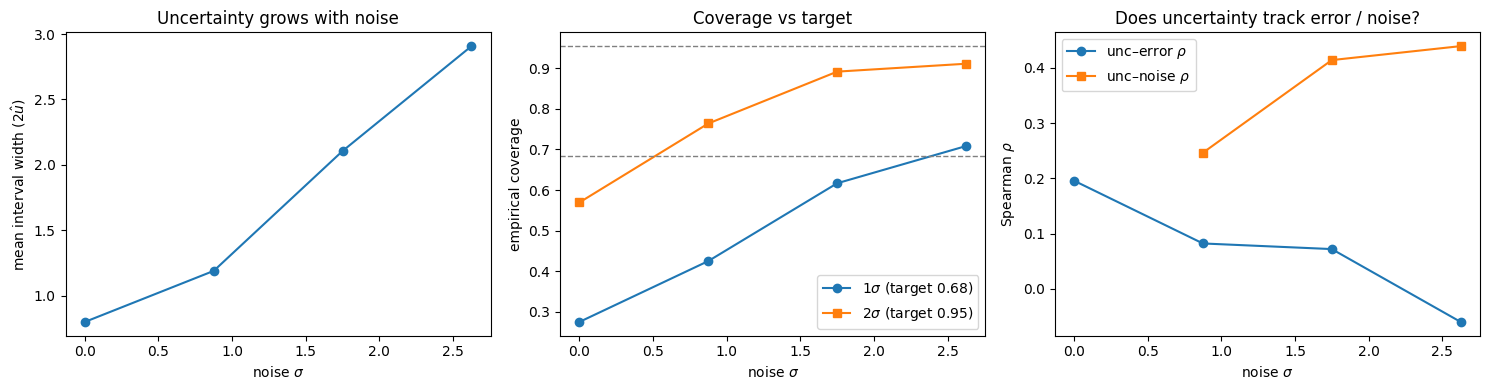

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
s = per_sigma_df['sigma']

axes[0].plot(s, per_sigma_df['mean_interval_width'], 'o-')
axes[0].set(xlabel='noise $\\sigma$', ylabel='mean interval width ($2\\hat u$)',
            title='Uncertainty grows with noise')

axes[1].plot(s, per_sigma_df['coverage_1sigma'], 'o-', label='1$\\sigma$ (target 0.68)')
axes[1].plot(s, per_sigma_df['coverage_2sigma'], 's-', label='2$\\sigma$ (target 0.95)')
axes[1].axhline(0.6827, ls='--', c='gray', lw=1)
axes[1].axhline(0.9545, ls='--', c='gray', lw=1)
axes[1].set(xlabel='noise $\\sigma$', ylabel='empirical coverage', title='Coverage vs target')
axes[1].legend()

axes[2].plot(s, per_sigma_df['unc_error_rho'], 'o-', label='unc–error $\\rho$')
axes[2].plot(s, per_sigma_df['unc_noise_rho'], 's-', label='unc–noise $\\rho$')
axes[2].set(xlabel='noise $\\sigma$', ylabel='Spearman $\\rho$',
            title='Does uncertainty track error / noise?')
axes[2].legend()

plt.tight_layout()
plt.show()

## Where to go next

- Swap NGBoost for `noiseInject.wrappers.GaucheGPRegressor` (fingerprint kernels),
  `SplitConformalRegressor` (distribution-free intervals around any sklearn model), or
  `MCDropoutRegressor` (PyTorch) — all expose the same `predict -> (mean, uncertainty)`
  interface used above. Install with `pip install noiseInject[uncertainty]`.
- Compare conditions at **matched amount**: rerun the sweep with `'student_t_nu3'`,
  `'outlier_p10'` or `'censoring_25'` and see which models keep `unc–noise ρ` high.
  Note that for `'gaussian'`, `'student_t_*'` and `'laplace'` every record gets the same
  noise scale, so "which records are unreliable" is **undefined**, not zero -- the result
  says so in `scale_is_degenerate`. `'grouped_wider'` and `'censoring_*'` are the
  conditions where there is a pattern to find.